## Decision Tree

- A decision tree is a non-parametric supervised learning algorithm, which is utilized for both classification and regression tasks. It has a hierarchical, tree structure, which consists of a root node, branches, internal nodes and leaf nodes.
- Model decides set of rules on training data and then make predictions.

- Decision tree are series of if-else question that splits data into more homogenous groups.
    - For regression, each leaf predicts mean of target value.
    - For classification, each leaf predicts the majority class.

In [18]:
import numpy as np
import pandas as pd

x = np.array([
    [25, 50000],
    [30, 60000],
    [35, 80000],
    [40, 90000],
    [45, 120000],
    [50, 150000]
])

y = np.array([0, 0, 0, 1, 1, 1])  # binary outcome

df = pd.DataFrame(x, columns=["age", "salary"])
df["label"] = y
df

,age,salary,label
0,25,50000,0
1,30,60000,0
2,35,80000,0
3,40,90000,1
4,45,120000,1
5,50,150000,1


### What kind of rule might separate the classes ?

- From observing data when age is greater than or equal to 40 and salary is grater than or equal to 90000 class is '1' else '0'.

In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

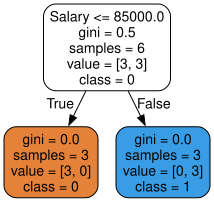

In [20]:
from sklearn.tree import export_graphviz
from graphviz import Source

export_graphviz(model, out_file="decision_tree_model.dot", feature_names=["Age", "Salary"], class_names=["0", "1"], rounded=True, filled=True)
Source.from_file(filename="decision_tree_model.dot")

### What does “training” mean for a tree ?

- For tree training means selecting features to use as conditions and if-else conditions for fitting given data.

In [21]:
model.predict(x)

array([0, 0, 0, 1, 1, 1])

### Why trees can get 100% training accuracy ?

- If labels or target values have distinct features to define them then tree will be created in such way that every leaf node will be pure and thus 100% fitting the training data (overfitting). or it will create if-else conditions in such way that it will overfit the data and become 100% accurate.

## Tree Complexity

- We can control how many conditions tree will decide or how much depth an decision tree will have. This control helps us from overfitting over training data and thus preventing it prediction's accuracy over unseen data.
- Depth and overfitting are directly related as we increase depth of tree model tends to overfit since there are more conditions to accurately define training data.  

In [22]:
for depth in [1, 2, 3]:
    
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x, y)
    
    print(depth, model.score(x, y))

1 1.0
2 1.0
3 1.0


## How Tree decides split ?

- Trees try all features and many thresholds then pick the split that reduces impurity the most.

### In Regression

- In regression tree checks impurity by calculating MSE (Mean Squared Error). we calculate MSE for many thresholds and features and select one with minimum MSE and we continue this until some minimum amount of data point are their in leaf node else model will overfit the given data.

### In Classification

- In classification tree checks impurity by calculating Gini impurity and select feature with the least gini impurity. we calculate it by 

    - **Gini impurity for leaf node = 1 - (probability of "class-1") - (probability of "class-2") - ... - (probability of "class-n")**

    - **Total Gini impurity = weighted average of Gini impurity of leaves**

## Why trees are powerful ?

- Decision trees are powerful in machine learning due to their ability to model complex, non-linear relationships and handle both numerical and categorical data without requiring feature scaling or normalization.

## Why trees are dangerous ?

- Very High variance, easily overfits the training data and are sensitive to small changes or noise 

## Bias–Variance tradeoff in Decision tree Regressor

In [23]:
from sklearn.datasets import make_regression

x, y = make_regression(n_samples=1000, n_features=3, n_informative=3, noise=0.1, random_state=42)   

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

def bias_of_decision_tree(x, y, max_depth, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    return bias2

In [25]:
def variance_of_decision_tree(x, y, max_depth, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return variance

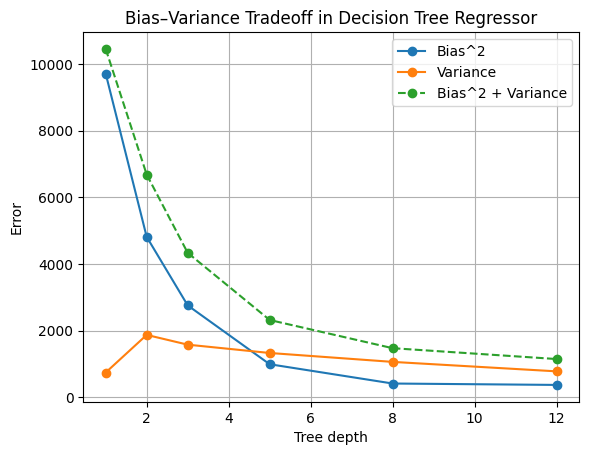

In [26]:
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 8, 12, None]

biases = []
variances = []
total_error = []

for depth in depths:
    
    b = bias_of_decision_tree(x, y, depth, 200)
    v = variance_of_decision_tree(x, y, depth, 200)
    
    biases.append(b)
    variances.append(v)
    total_error.append(b + v)
    

plt.plot(depths, biases, marker="o", label="Bias^2")
plt.plot(depths, variances, marker="o", label="Variance")
plt.plot(depths, total_error, marker="o", linestyle="--", label="Bias^2 + Variance")

plt.xlabel("Tree depth")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff in Decision Tree Regressor")
plt.legend()
plt.grid(True)

## Bias–Variance tradeoff in Decision tree Classifier

In [27]:
from sklearn.datasets import make_classification

x, y = make_classification(n_samples=1000, n_features=3, n_informative=3, n_redundant=0, n_classes=2, random_state=42)   

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

def bias_of_decision_tree(x, y, max_depth, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    return bias2

In [29]:
def variance_of_decision_tree(x, y, max_depth, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return variance

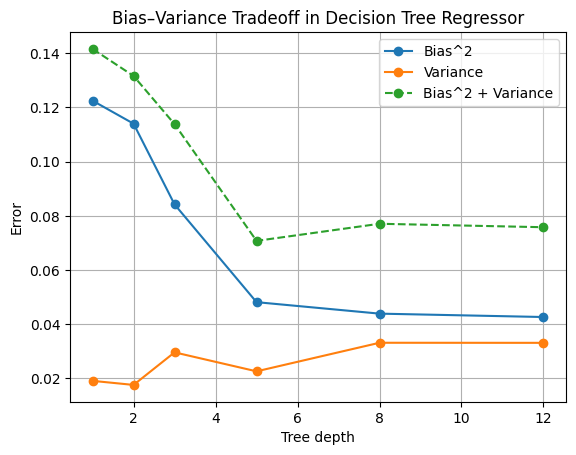

In [30]:
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 8, 12, None]

biases = []
variances = []
total_error = []

for depth in depths:
    
    b = bias_of_decision_tree(x, y, depth, 200)
    v = variance_of_decision_tree(x, y, depth, 200)
    
    biases.append(b)
    variances.append(v)
    total_error.append(b + v)
    

plt.plot(depths, biases, marker="o", label="Bias^2")
plt.plot(depths, variances, marker="o", label="Variance")
plt.plot(depths, total_error, marker="o", linestyle="--", label="Bias^2 + Variance")

plt.xlabel("Tree depth")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff in Decision Tree Regressor")
plt.legend()
plt.grid(True)